<a href="https://colab.research.google.com/github/avionerman/AML/blob/main/02_adversarial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Adversarial Robustness Evaluation

**Στοχος:** Να μετρησουμε ποσο ευρωστο ειναι το μοντελο σε επιθεσεις adversarial
perturbations. Χρησιμοποιουμε:

- **AutoAttack** (Croce & Hein, ICML 2020) — το gold standard για robust accuracy.
- **TorchAttacks** — FGSM / DeepFool / CW για διαφορετικη γεωμετρια επιθεσης.
- **Madry-style PGD ε-sweep** — για το χαρακτηριστικο decay curve.
- **FGSM-vs-PGD gap** — diagnostic για gradient masking.

**Διαβαζει** απο `artefacts/01_training_{clean|pgd}/` — δεν εκπαιδευει τιποτα.
**Παραγει** το `artefacts/02_adversarial/`.


## 1. Setup

In [1]:
# Auto-detect environment (Colab vs local) and add src/ to sys.path.
import os, sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT = Path("/content/drive/MyDrive/rf_drone_defense")
else:
    # local: this notebook lives in <root>/notebooks/, src/ is one level up
    PROJECT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.insert(0, str(PROJECT))
print("Project root:", PROJECT)
print("Python:", sys.version.split()[0])

import torch
print("torch", torch.__version__, "| CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Mounted at /content/drive
Project root: /content/drive/MyDrive/rf_drone_defense
Python: 3.12.13
torch 2.10.0+cu128 | CUDA available: True
GPU: NVIDIA L4


In [2]:
from src.config import CFG, CLASS_NAMES, N_CLASSES
from src import data as data_mod
from src import model as model_mod
from src import attacks as atk_mod

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", DEVICE)


device: cuda


### 1.1 Επιλογη variant του εκπαιδευμενου μοντελου

Το notebook 01 παραγει **δυο εκδοχες** μοντελου (αν εχετε τρεξει και τα δυο passes):

- `artefacts/01_training_clean/`  → clean baseline (PGD off)
- `artefacts/01_training_pgd/`    → PGD-hardened

Διαλεξτε ποια θελετε να αναλυσετε αλλαζοντας **μια γραμμη** στο cell παρακατω.


In [35]:
import sys
for k in list(sys.modules):
    if k.startswith("src."):
        del sys.modules[k]
from src.config import CFG
CFG.use_adversarial_training = False   # για clean pass
print("Will save to:", CFG.artefacts("02_adversarial").name)
# Expected: 02_adversarial_clean


Will save to: 02_adversarial_clean


In [36]:
# === Επιλογη μοντελου προς αναλυση ===
# False -> διαβαζει απο artefacts/01_training_clean/
# True  -> διαβαζει απο artefacts/01_training_pgd/
CFG.use_adversarial_training = False

print(f"Reading artefacts from: {CFG.artefacts('01_training')}")
assert CFG.artefacts('01_training').exists(), (
    f"Folder missing: {CFG.artefacts('01_training')}. "
    "Have you run 01_training.ipynb for this variant yet?"
)


Reading artefacts from: /content/drive/MyDrive/rf_drone_defense/artefacts/01_training_clean


## 2. Φορτωνουμε το εκπαιδευμενο μοντελο και το test split

In [38]:
import gc
# Re-load dataset + splits (no retraining).
pack = data_mod.load_arrays(CFG.dataset_path, with_iq=False)
x_spec, y, snr = pack["x_spec"], pack["y"], pack["snr"]

splits_file = np.load(CFG.artefacts("01_training") / "splits.npz")
train_idx, val_idx, test_idx = splits_file["train"], splits_file["val"], splits_file["test"]

# Rebuild loaders WITHOUT augmentation (we attack the inference path, not training)
_, val_loader, test_loader = data_mod.make_loaders(
    (train_idx, val_idx, test_idx), x_spec, y, snr, cfg=CFG, augment_train=False,
)

model = model_mod.build_model(N_CLASSES).to(DEVICE)
ckpt = CFG.artefacts("01_training") / "checkpoints" / "best.pt"
state = torch.load(ckpt, map_location=DEVICE, weights_only=True)
model.load_state_dict(state)
model.eval()
print("Loaded checkpoint:", ckpt)


Loaded checkpoint: /content/drive/MyDrive/rf_drone_defense/artefacts/01_training_clean/checkpoints/best.pt


## 3. Sanity — clean test accuracy

In [39]:
n_correct = n_total = 0
with torch.no_grad():
    for xb, yb, _ in test_loader:
        xb = xb.to(DEVICE); yb_t = torch.as_tensor(yb, device=DEVICE)
        pred = model(xb).argmax(-1)
        n_correct += int((pred == yb_t).sum().item())
        n_total += int(xb.shape[0])
clean_acc = n_correct / n_total
print(f"Clean test accuracy: {clean_acc*100:.2f}% on {n_total} samples")


Clean test accuracy: 92.44% on 14806 samples


## 4. PGD ε-sweep (Madry et al., ICLR 2018)

{
  "0.00": "92.65%",
  "0.02": "59.10%",
  "0.05": "32.05%",
  "0.10": "18.05%",
  "0.15": "10.45%",
  "0.20": "5.20%",
  "0.30": "1.55%"
}


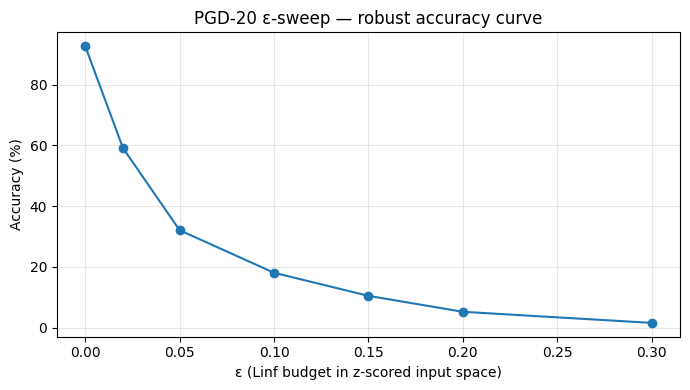

In [40]:
# Sweep on a subset for speed (full test is ~15 min on T4 for K=20).
# Take a stratified mini-test of 2000 samples.
rng = np.random.default_rng(42)
sub_idx = test_idx[rng.choice(len(test_idx), size=min(2000, len(test_idx)), replace=False)]
sub_loaders = data_mod.make_loaders(
    (train_idx, val_idx, sub_idx), x_spec, y, snr, cfg=CFG, augment_train=False,
)
sub_test_loader = sub_loaders[2]

eps_list = [0.0, 0.02, 0.05, 0.10, 0.15, 0.20, 0.30]
sweep = atk_mod.sweep_pgd(model, sub_test_loader, eps_list, alpha_frac=0.25, n_iters=20, device=DEVICE)
print(__import__("json").dumps({f"{k:.2f}": f"{v*100:.2f}%" for k, v in sweep.items()}, indent=2))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sweep.keys()), [v * 100 for v in sweep.values()], marker="o")
ax.set_xlabel("ε (Linf budget in z-scored input space)"); ax.set_ylabel("Accuracy (%)")
ax.set_title("PGD-20 ε-sweep — robust accuracy curve")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(CFG.figures("02_adversarial") / "pgd_eps_sweep.png", dpi=120)
plt.show()


**Σχολιο:** Ενα μοντελο χωρις adversarial training θα δειξει απoτομη πτωση
και στα ε=0.02. Ενα PGD-trained μοντελο θα διατηρει το χαμηλο decay μεχρι το
trained ε και θα καταρρεει αποτομα ακριβως μετα — αυτη ειναι η υπογραφη του
Madry-style defence.


## 5. FGSM-vs-PGD gap (gradient-masking diagnostic)

In [41]:
gap = atk_mod.fgsm_vs_pgd_gap(model, sub_test_loader, eps=0.10, device=DEVICE)
print(__import__("json").dumps(gap, indent=2))
print()
if gap["gap_pp"] > 10.0:
    print("⚠️  Gap > 10 pp → πιθανο gradient masking. Δεν εμπιστευομαστε τη robustness.")
else:
    print("✅ Gap ≤ 10 pp → καθαρο gradient signal, η robustness ειναι πραγματικη.")


{
  "fgsm_acc": 0.306,
  "pgd_acc": 0.1795,
  "gap_pp": 12.65
}

⚠️  Gap > 10 pp → πιθανο gradient masking. Δεν εμπιστευομαστε τη robustness.


## 6. AutoAttack (gold-standard)

In [42]:
import sys
for k in list(sys.modules):
    if k.startswith("autoattack"):
        del sys.modules[k]

# Fresh import — θα παρει το original AutoAttack.__init__ (χωρις το σπασμενο patch)
import importlib, src.attacks
importlib.reload(src.attacks)
from src import attacks as atk_mod

# Sanity
from autoattack import AutoAttack
print("AutoAttack.__init__ →", AutoAttack.__init__.__qualname__)
print("Expected: 'AutoAttack.__init__' (NOT '_patched_init')")


AutoAttack.__init__ → AutoAttack.__init__
Expected: 'AutoAttack.__init__' (NOT '_patched_init')


In [43]:
# AutoAttack is slow — run on a 500-sample stratified subset.
sub2 = test_idx[rng.choice(len(test_idx), size=min(500, len(test_idx)), replace=False)]
xb_list = []; yb_list = []
for xb, yb, _ in data_mod.make_loaders(
    (train_idx, val_idx, sub2), x_spec, y, snr, cfg=CFG, augment_train=False,
)[2]:
    xb_list.append(xb); yb_list.append(torch.as_tensor(yb))
X = torch.cat(xb_list, dim=0).to(DEVICE); Y = torch.cat(yb_list).to(DEVICE)

try:
    adv_X, aa_metrics = atk_mod.autoattack_eval(model, X, Y, eps=0.10, version="standard")
    print(__import__("json").dumps(aa_metrics, indent=2))
except RuntimeError as e:
    print("AutoAttack not installed:", e)
    print("Install with: !pip install git+https://github.com/fra31/auto-attack")
    aa_metrics = None


{
  "clean_acc": 0.9240000247955322,
  "adv_acc": 0.08400000631809235
}


## 7. TorchAttacks (FGSM / DeepFool / CW)

In [21]:
!pip install -q torchattacks


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 15.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
google-genai 1.68.0 requires requests<3.0.0,>=2.28.1, but you have requests 2.25.1 which is incompatible.
pysal 25.7 requires requests>=2.27, but you have requests 2.25.1 which is incompatible.
blobfile 3.2.0 requires urllib3>=2, but you have urlli

In [44]:
results_ta = {}
ta = atk_mod._try_import_torchattacks()
if ta is None:
    print("torchattacks not installed. !pip install torchattacks")
else:
    for name, fn in [
        ("FGSM", lambda x, y: atk_mod.torchattacks_fgsm(model, x, y, eps=0.10)),
        ("DeepFool", lambda x, y: atk_mod.torchattacks_deepfool(model, x, y, steps=20)),
        # CW is heavy — small subset
        ("CW", lambda x, y: atk_mod.torchattacks_cw(model, x, y, steps=30)),
    ]:
        adv = fn(X[:200], Y[:200])
        with torch.no_grad():
            acc = (model(adv).argmax(-1) == Y[:200]).float().mean().item()
        results_ta[name] = float(acc)
        print(f"{name:>10}: {acc*100:.2f}%")


      FGSM: 20.00%
  DeepFool: 9.00%
        CW: 19.00%


## 8. Persistence

In [45]:
import json
out = CFG.artefacts("02_adversarial")
summary = {
    "clean_acc": clean_acc,
    "pgd_eps_sweep": {f"{k:.4f}": float(v) for k, v in sweep.items()},
    "fgsm_vs_pgd_gap": gap,
    "autoattack": aa_metrics,
    "torchattacks": results_ta,
    "eps_used": 0.10,
}
with (out / "adversarial_results.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str)
print("Saved:", out / "adversarial_results.json")


Saved: /content/drive/MyDrive/rf_drone_defense/artefacts/02_adversarial_clean/adversarial_results.json
